In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('benchmark.csv')

# ADD VIRTUAL ROWS FOR V6 higher params
v6k0 = df.query('(version == "V6") & (test == "k0")')[['date', 'seed', 'device', 'exetime']].rename(columns={'exetime': 'exetime_one'})
v8k0 = df.query('(version == "V8") & (test == "k0") & (val != 1)')
merged = v8k0.merge(v6k0, on=['date', 'seed', 'device'], how='right')
merged['exetime'] = merged['exetime_one'] * merged['val']
merged['version'] = 'V6'
merged.drop(columns=['exetime_one'], inplace=True)

df = pd.concat([df, merged])

df = df.sort_values(['device', 'date', 'seed', 'val', 'version']).copy().reset_index(drop=True)
df

,date,seed,test,val,version,device,exetime,power
0,20111116,72,k0,1,V8,A100,11.206006,4211.259
1,20111116,72,k0,2,V8,A100,19.331809,7782.444
2,20111116,72,k0,4,V8,A100,37.405288,15341.953
3,20111116,72,k0,8,V8,A100,73.590815,30480.612
4,20111116,72,k0,16,V8,A100,146.358778,60793.440
...,...,...,...,...,...,...,...,...
2875,20180929,861,part,4096,V8,RTX 3090,6.405465,3867.723
2876,20180929,861,part,8192,V8,RTX 3090,8.741194,6115.383
2877,20180929,861,part,16384,V8,RTX 3090,16.702437,11910.914
2878,20180929,861,part,32768,V8,RTX 3090,36.555249,23741.308


In [3]:
# TEMPORARY DROP RTX 3090 HIGH PARAMS
df = df.drop(df.query('(device == "RTX 3090") & (test == "k0") & (val in [64, 128])').index)

[None, None, Text(0.5, 0, '# param'), Text(0, 0.5, 'time (s)')]

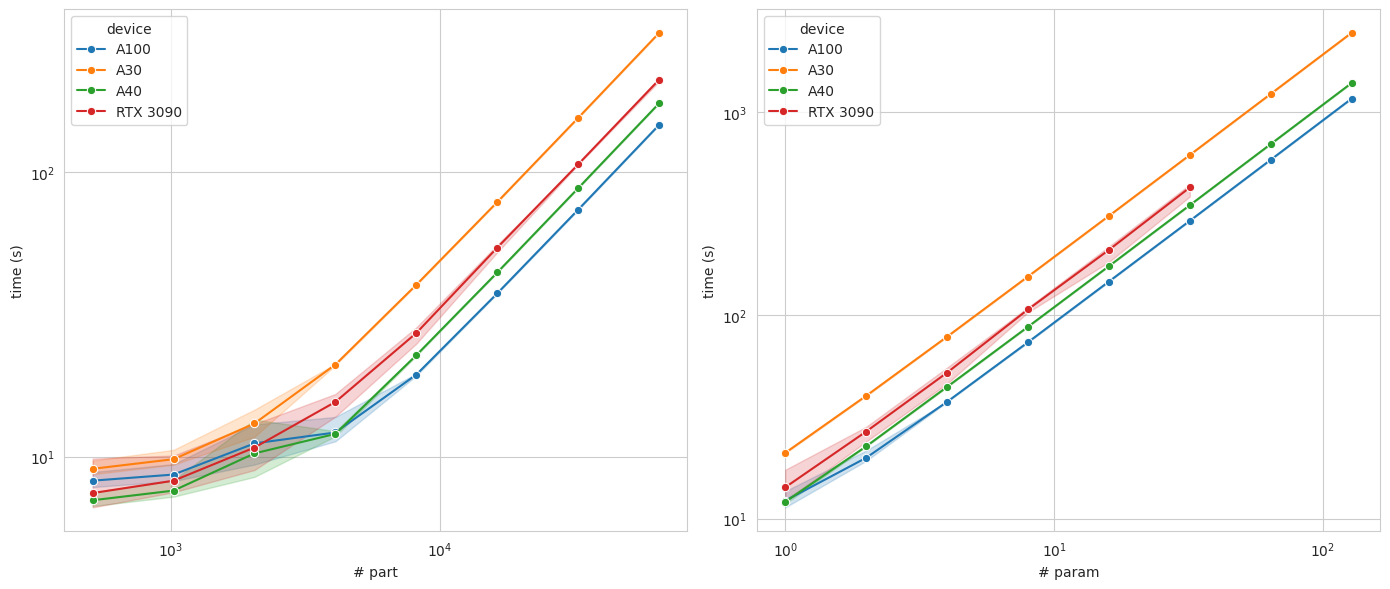

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df.query('(version == "V8") & (test == "part") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[0],
)
ax1.set(xscale='log', yscale='log', xlabel='# part', ylabel='time (s)')

ax2 = sns.lineplot(
    data=df.query('(version == "V8") & (test == "k0") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[1],
)
ax2.set(xscale='log', yscale='log', xlabel='# param', ylabel='time (s)')

[None, None, Text(0.5, 0, '# param'), Text(0, 0.5, 'time (s)')]

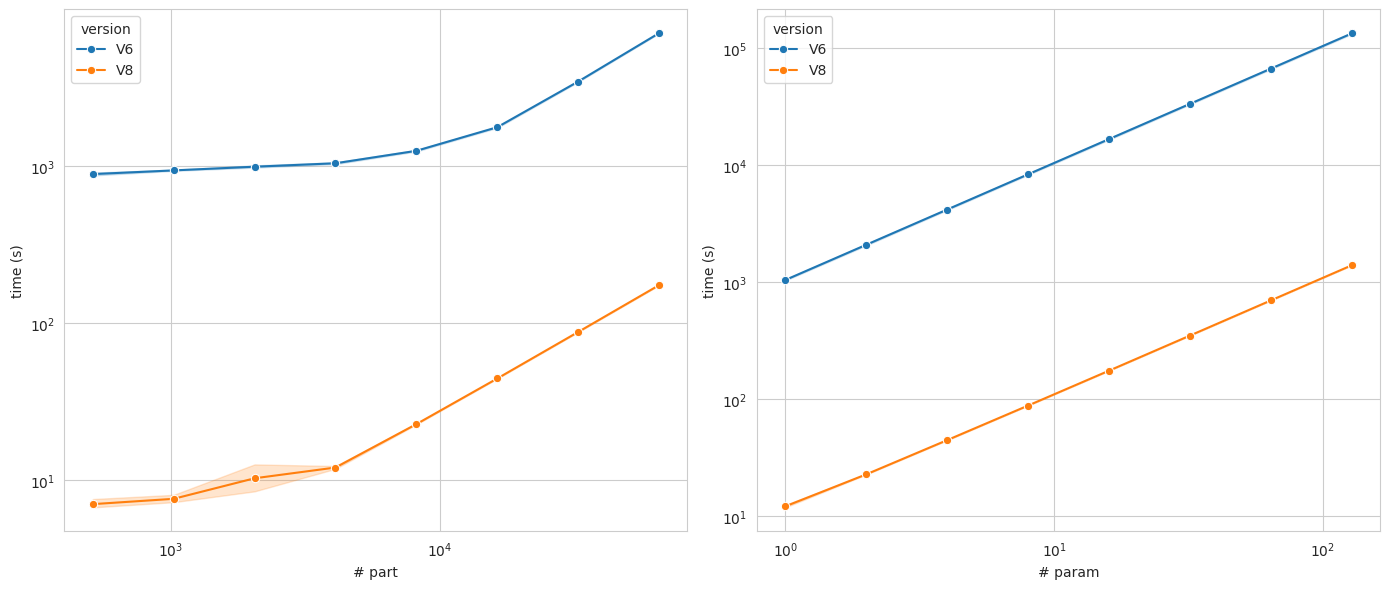

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df.query('(device == "A40") & (test == "part") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='version',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[0],
)
ax1.set(xscale='log', yscale='log', xlabel='# part', ylabel='time (s)')

ax2 = sns.lineplot(
    data=df.query('(device == "A40") & (test == "k0") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='version',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[1],
)
ax2.set(xscale='log', yscale='log', xlabel='# param', ylabel='time (s)')

[None, Text(0.5, 0, '# param'), Text(0, 0.5, 'speedups (x times)')]

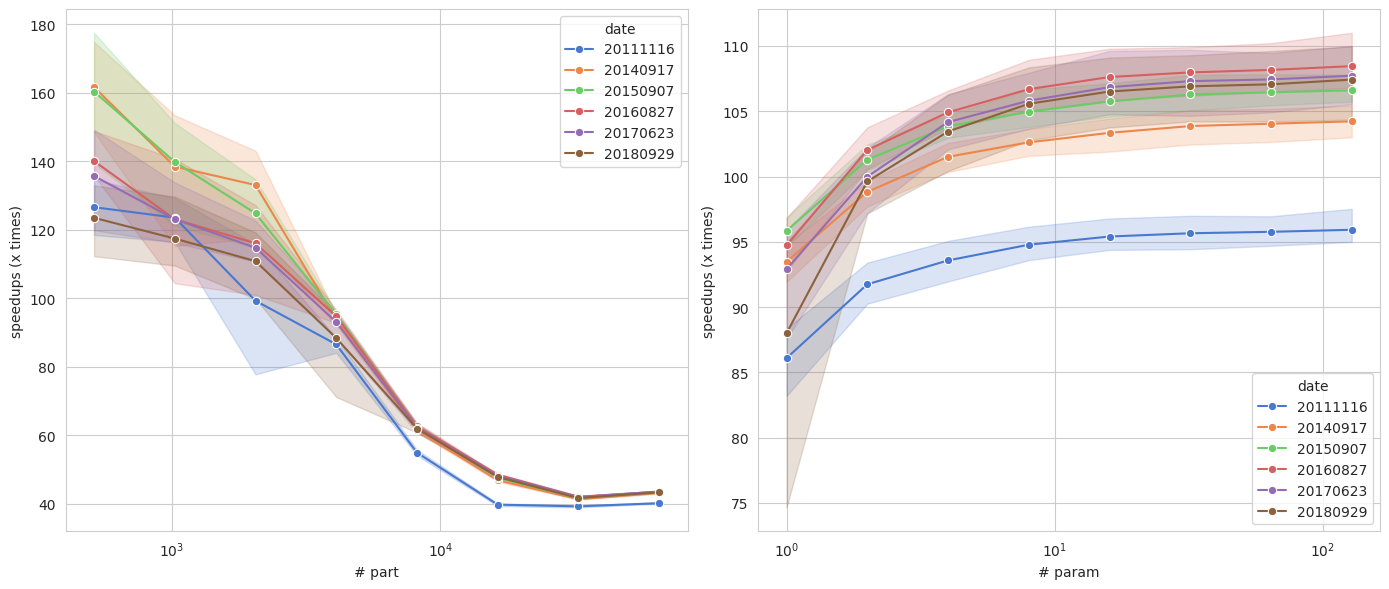

In [6]:
df_ = pd.merge(
    df.query('(device == "A40") & (version == "V6")'),
    df.query('(device == "A40") & (version == "V8")'),
    on=['date', 'seed', 'test', 'val', 'device'],
)
df_['ratio'] = df_['exetime_x'] / df_['exetime_y']

fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df_.query('test == "part"'),
    x='val',
    y='ratio',
    hue='date',
    marker='o',
    errorbar=('ci', 100),
    palette='muted',
    ax=ax[0],
)
ax1.set(xscale='log', xlabel='# part', ylabel='speedups (x times)')

ax2 = sns.lineplot(
    data=df_.query('test == "k0"'),
    x='val',
    y='ratio',
    hue='date',
    marker='o',
    errorbar=('ci', 100),
    palette='muted',
    ax=ax[1],
)
ax2.set(xscale='log', xlabel='# param', ylabel='speedups (x times)')

<Axes: xlabel='device', ylabel='power'>

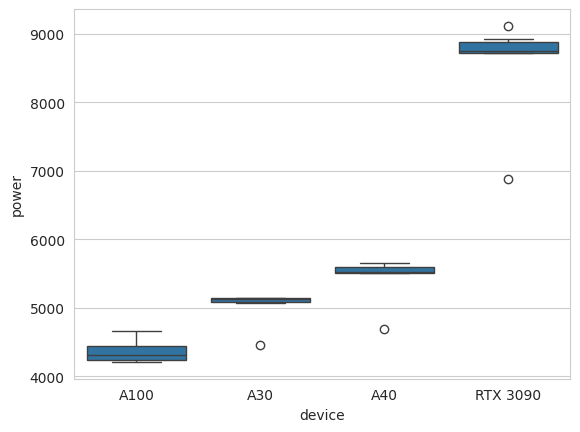

In [19]:
sns.boxplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "k0") & (val == 1)'),
    x='device',
    y='power',
)

[None, None, Text(0.5, 0, '# part'), Text(0, 0.5, 'power consumption (W)')]

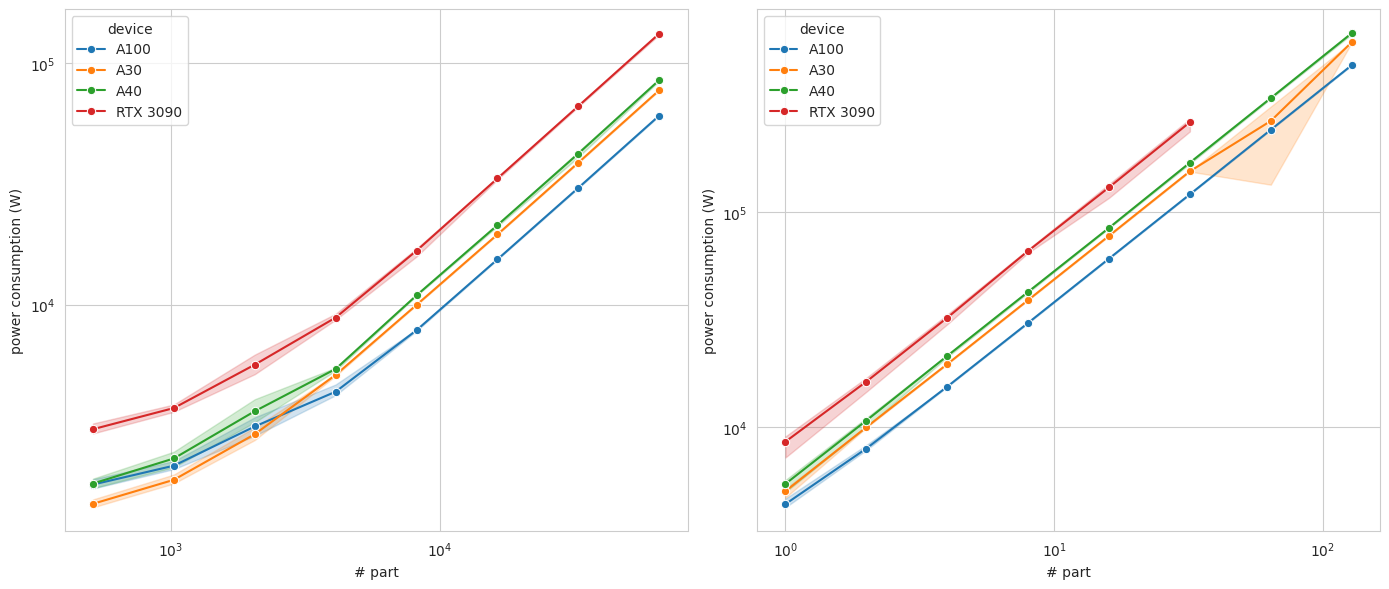

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "part")'),
    x='val',
    y='power',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    markers='o',
    ax=ax[0],
)
ax1.set(xscale='log', yscale='log', xlabel='# part', ylabel='power consumption (W)')

ax2 = sns.lineplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "k0")'),
    x='val',
    y='power',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    markers='o',
    ax=ax[1],
)
ax2.set(xscale='log', yscale='log', xlabel='# part', ylabel='power consumption (W)')